In [1]:
import skimage
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import os
from tqdm import tqdm
import subprocess

## Only clean BBBC039 and our data, find a threshold

In [2]:
PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/'
df = pd.read_csv(os.path.join(PATH, 'metadata.csv'))
df_sub = df[df.datasets.isin(['BBBC039', 'mnDINO_data_01', 'mnDINO_data_02'])]
df.head()

,filenames,datasets,magnification,micron,split,cell_line
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.5,train,HeLa
1,C1-20X_c0_B3_Tile-24.tif,mnDINO_data_02,20,6.5,validation,HeLa
2,C1-20X_c0_B3_Tile-15.tif,mnDINO_data_02,20,6.5,test,HeLa
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.5,train,RPE1
4,C1-20X_c0_phalloidin_C3_Tile-15.tif,mnDINO_data_02,20,6.5,validation,RPE1


In [6]:
df[df.datasets.isin(['mnDINO_data_01'])]

,filenames,datasets,magnification,micron,split,cell_line
6,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,14,4.25,train,HeLa
7,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,14,4.25,train,HeLa
8,C2-20X_c0-DAPI-GFP_A1_Tile-5.tif,mnDINO_data_01,14,4.25,test,HeLa
9,C2-20X_c0-DAPI-GFP_B3_Tile-16.tif,mnDINO_data_01,14,4.25,validation,HeLa
10,20X_c0-DAPI_A1_Tile-50.tif,mnDINO_data_01,14,4.25,validation,HeLa
11,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,14,4.25,train,HeLa
12,20X_c0-DAPI_A1_Tile-70.tif,mnDINO_data_01,14,4.25,train,HeLa
13,20X_c0-DAPI_A1_Tile-110.tif,mnDINO_data_01,14,4.25,train,HeLa
14,20X_c0-DAPI_A1_Tile-10.tif,mnDINO_data_01,14,4.25,train,HeLa
15,C2-20X_c0-DAPI-GFP_A2_Tile-5.tif,mnDINO_data_01,14,4.25,validation,HeLa


In [3]:
df.shape

(232, 6)

In [ ]:
df[(df.datasets.isin(['mnDINO_data_01', 'mnDINO_data_02']) & (df.split == 'train'))]

,filenames,datasets,magnification,micron,split,cell_line
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.50,train,HeLa
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.50,train,RPE1
6,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,14,4.25,train,HeLa
7,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,14,4.25,train,HeLa
11,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,14,4.25,train,HeLa
12,20X_c0-DAPI_A1_Tile-70.tif,mnDINO_data_01,14,4.25,train,HeLa
13,20X_c0-DAPI_A1_Tile-110.tif,mnDINO_data_01,14,4.25,train,HeLa
14,20X_c0-DAPI_A1_Tile-10.tif,mnDINO_data_01,14,4.25,train,HeLa
16,C2-20X_c0-DAPI-GFP_B1_Tile-8.tif,mnDINO_data_01,14,4.25,train,HeLa
17,C2-20X_c0-DAPI-GFP_A3_Tile-6.tif,mnDINO_data_01,14,4.25,train,HeLa


In [ ]:
# LOAD_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/all_data_micronuclei_no_rescale/train/'
# SAVE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/train/mn_masks/'
# # im = skimage.io.imread(os.path.join(LOAD_PATH, 'C1-20X_c0_B3_Tile-5.phenotype_outlines.png'))
# # plt.imshow(im)
# train_files = df[(df.datasets.isin(['mnDINO_data_01', 'mnDINO_data_02']) & (df.split == 'train'))]
# for filename in tqdm(train_files.filenames.to_list(), total=len(train_files)):
#     load_file_name = filename.replace('.tif', '.phenotype_outlines.png')
#     save_file_name = filename.replace('.tif', '.png')
#     subprocess.run(f'cp {os.path.join(LOAD_PATH, load_file_name)} {os.path.join(SAVE_PATH, save_file_name)}', shell=True, text=True)
    

100%|██████████| 14/14 [00:00<00:00, 64.90it/s]


In [ ]:
PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/'

AREA_THRESHOLD = 5
MARGIN = 10

for i, row in tqdm(df_sub.iterrows()):
    subset = row.split
    mn_mask_name = row.filenames.replace('.tif', '.png')
    MASK_PATH = os.path.join(PATH, subset, 'mn_masks', mn_mask_name)
    # print(MASK_PATH)
    
    mask = skimage.io.imread(MASK_PATH)
    labels = skimage.morphology.label(mask)
    targets = []
    H,W = labels.shape
    need_to_resave = False
    for j in range(1, np.max(labels) + 1):
        area = np.sum(labels == j)
        ys, xs = np.where(labels == j)
        y, x = np.mean(ys), np.mean(xs)
        if area <= AREA_THRESHOLD:
            targets.append(j)
            need_to_resave = True
        if row.datasets == 'BBBC039':
            if ((y - MARGIN <= 0) | (y + MARGIN >= H) | (x - MARGIN <= 0) | (x + MARGIN >= W)): # if close to margin, targets to remove
                targets.append(j)
                need_to_resave = True
    if need_to_resave: # len(targets) > 0
        for target in targets:
            labels[labels == target] = 0
    # new_mask = np.isin(labels, targets)
    # new_labels = skimage.morphology.label(new_mask)
    # new_labels = np.asarray(new_labels, dtype=np.uint16)
        new_labels = skimage.morphology.label(labels)
        new_labels = np.asarray(new_labels, dtype=np.uint16)
        print(f'Resaved MASK: {mn_mask_name}')
        skimage.io.imsave(MASK_PATH, new_labels)

0it [00:00, ?it/s]/tmp/ipykernel_615185/773921099.py:37: UserWarning: /hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/train/mn_masks/C1-20X_c0_B3_Tile-5.png is a low contrast image
  skimage.io.imsave(MASK_PATH, new_labels)
1it [00:02,  2.60s/it]

Resaved MASK: C1-20X_c0_B3_Tile-5.png


2it [00:07,  3.85s/it]/tmp/ipykernel_615185/773921099.py:37: UserWarning: /hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/test/mn_masks/C1-20X_c0_B3_Tile-15.png is a low contrast image
  skimage.io.imsave(MASK_PATH, new_labels)
3it [00:10,  3.68s/it]

Resaved MASK: C1-20X_c0_B3_Tile-15.png


10it [00:28,  2.82s/it]/tmp/ipykernel_615185/773921099.py:37: UserWarning: /hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/validation/mn_masks/20X_c0-DAPI_A1_Tile-50.png is a low contrast image
  skimage.io.imsave(MASK_PATH, new_labels)
11it [00:33,  3.65s/it]

...

Resaved MASK: IXMtest_C18_s1_w11C16FC59-2E29-496A-803A-89581FDF538A.png


121it [01:14, 44.23it/s]/tmp/ipykernel_615185/773921099.py:37: UserWarning: /hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/test/mn_masks/IXMtest_J16_s8_w1AD7BC3EB-6A29-4A53-AA59-E39653839B0D.png is a low contrast image
  skimage.io.imsave(MASK_PATH, new_labels)
132it [01:14, 54.60it/s]/tmp/ipykernel_615185/773921099.py:37: UserWarning: /hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/train/mn_masks/IXMtest_P05_s5_w18FC141F8-8BCA-4851-9000-31D080922BDD.png is a low contrast image
  skimage.io.imsave(MASK_PATH, new_labels)


Resaved MASK: IXMtest_J16_s8_w1AD7BC3EB-6A29-4A53-AA59-E39653839B0D.png
Resaved MASK: IXMtest_P05_s5_w18FC141F8-8BCA-4851-9000-31D080922BDD.png


163it [01:14, 73.69it/s]/tmp/ipykernel_615185/773921099.py:37: UserWarning: /hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/train/mn_masks/IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2CEA6BE2.png is a low contrast image
  skimage.io.imsave(MASK_PATH, new_labels)
182it [01:14,  2.43it/s]

Resaved MASK: IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2CEA6BE2.png


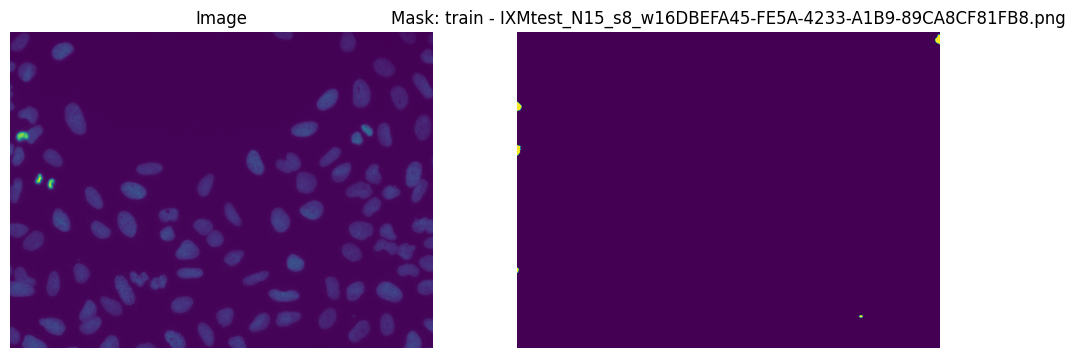

100%|██████████| 183/183 [02:14<00:00,  1.36it/s]


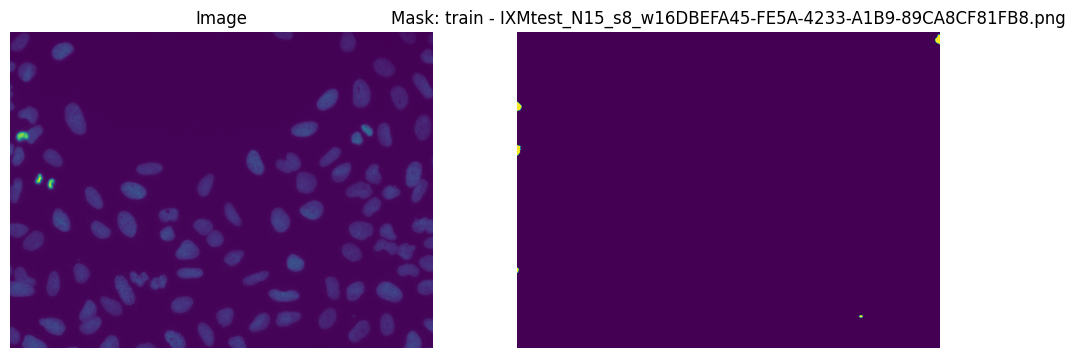

In [4]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import skimage.io
import time

PATH = '/scr/yren/annotated_mn_datasets/'
fig, ax = plt.subplots(1, 2, figsize=(12, 12))

for _, row in tqdm(df_sub.iterrows(), total=len(df_sub)):
    clear_output(wait=True)   # <-- clear previous output

    subset = row.split
    mn_mask_name = row.filenames.replace('.tif', '.png')

    IMG_PATH = os.path.join(PATH, subset, 'images', row.filenames)
    MASK_PATH = os.path.join(PATH, subset, 'mn_masks', mn_mask_name)

    img = skimage.io.imread(IMG_PATH)
    mask = skimage.io.imread(MASK_PATH)

    ax[0].cla()
    ax[1].cla()

    ax[0].imshow(img)
    ax[0].set_title("Image")
    ax[0].axis("off")

    ax[1].imshow(mask > 0)
    ax[1].set_title(f"Mask: {subset} - {mn_mask_name}")
    ax[1].axis("off")

    time.sleep(0.5)
    display(fig)


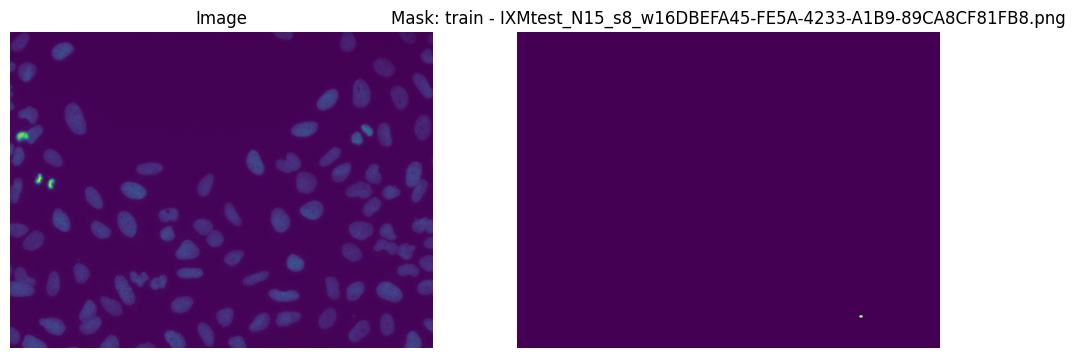

100%|██████████| 183/183 [02:14<00:00,  1.36it/s]


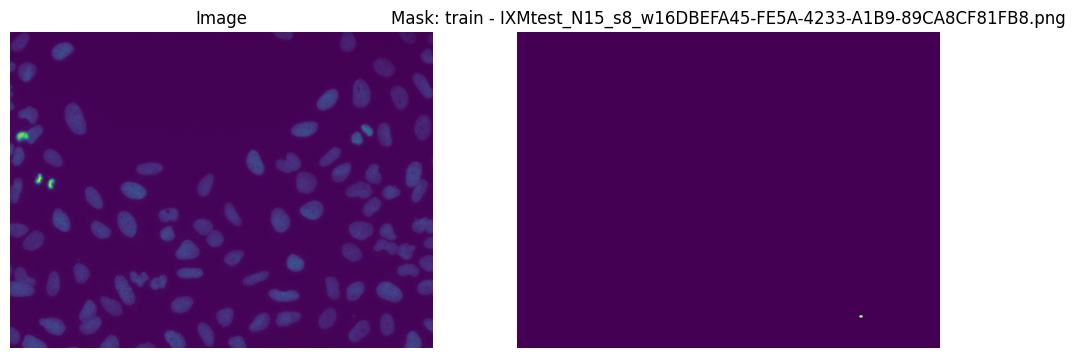

In [5]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import skimage.io
import time

PATH = '/scr/yren/cleaned_annotated_mn_datasets/'
fig, ax = plt.subplots(1, 2, figsize=(12, 12))

for _, row in tqdm(df_sub.iterrows(), total=len(df_sub)):
    clear_output(wait=True)   # <-- clear previous output

    subset = row.split
    mn_mask_name = row.filenames.replace('.tif', '.png')

    IMG_PATH = os.path.join(PATH, subset, 'images', row.filenames)
    MASK_PATH = os.path.join(PATH, subset, 'mn_masks', mn_mask_name)

    img = skimage.io.imread(IMG_PATH)
    mask = skimage.io.imread(MASK_PATH)

    ax[0].cla()
    ax[1].cla()

    ax[0].imshow(img)
    ax[0].set_title("Image")
    ax[0].axis("off")

    ax[1].imshow(mask > 0)
    ax[1].set_title(f"Mask: {subset} - {mn_mask_name}")
    ax[1].axis("off")

    time.sleep(0.5)
    display(fig)


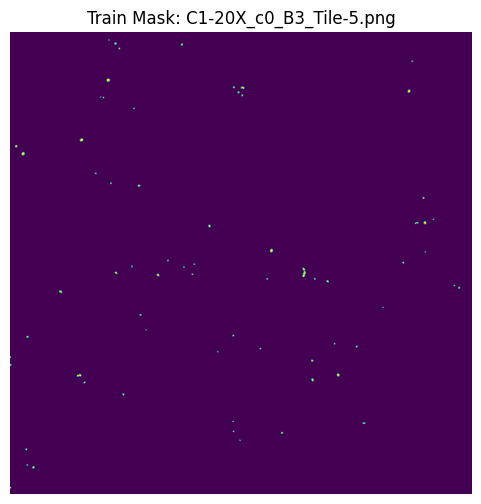

In [32]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import os
import skimage.io
import time

PATH = '/scr/yren/cleaned_our_data/'

files = os.listdir(PATH)
for file in files:
    clear_output(wait=True)

    MASK_PATH = os.path.join(PATH, file)
    mask = skimage.io.imread(MASK_PATH)

    plt.figure(figsize=(6, 6))
    plt.title(f"Train Mask: {file}")
    plt.imshow(mask > 0)
    plt.axis("off")
    plt.show()

    time.sleep(0.5)


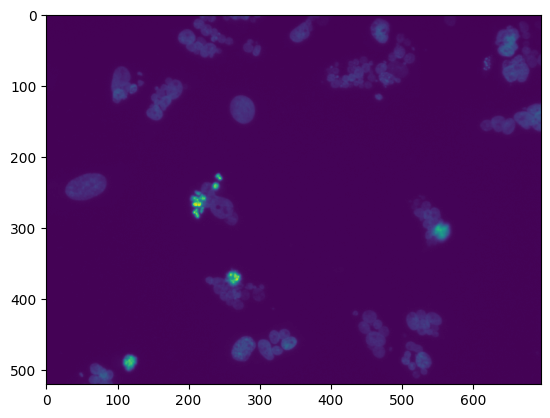

In [7]:
PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/old/old_annotated_mn_datasets/'
mn_mask_name = 'IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-5681452CCD1D.tif'
MASK_PATH = os.path.join(PATH, 'train', 'images', mn_mask_name)
mask = skimage.io.imread(MASK_PATH)

plt.imshow(mask)

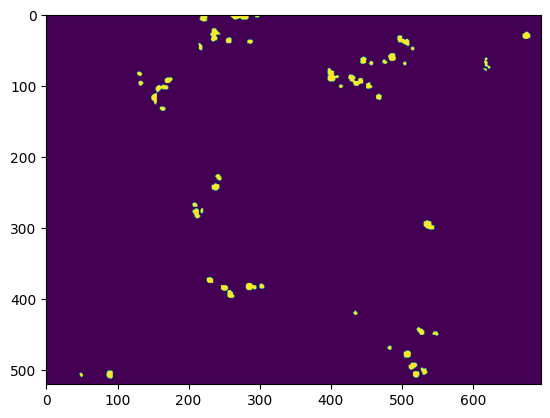

In [2]:
PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/old/old_annotated_mn_datasets/'
mn_mask_name = 'IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-5681452CCD1D.png'
MASK_PATH = os.path.join(PATH, 'train', 'mn_masks', mn_mask_name)
mask = skimage.io.imread(MASK_PATH)

plt.imshow(mask > 0)

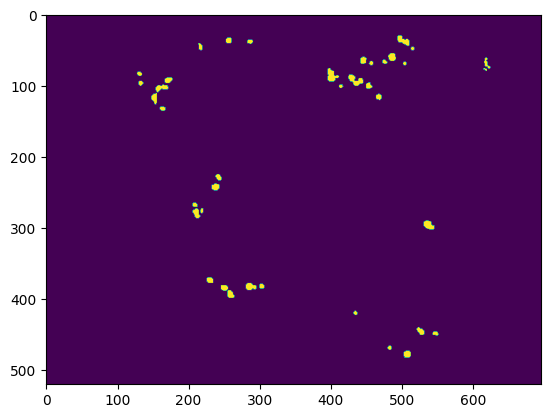

In [3]:
PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/cleaned_annotated_mn_datasets/'
mn_mask_name = 'IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-5681452CCD1D.png'
MASK_PATH = os.path.join(PATH, 'train', 'mn_masks', mn_mask_name)
mask = skimage.io.imread(MASK_PATH)

plt.imshow(mask > 0)

(2720, 2720)


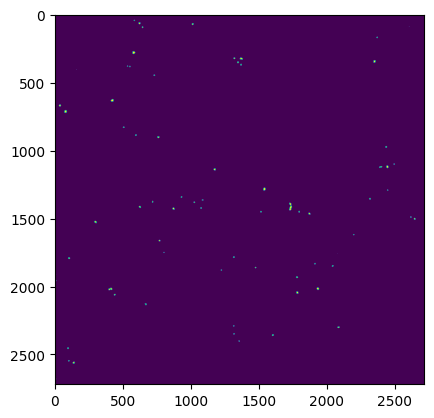

In [5]:
PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/all_data_micronuclei_no_rescale/'
mn_mask_name = 'C1-20X_c0_B3_Tile-5.phenotype_outlines.png'
MASK_PATH = os.path.join(PATH, 'train', mn_mask_name)
mask = skimage.io.imread(MASK_PATH)
print(mask.shape)

plt.imshow(mask > 0)

(2960, 2960)


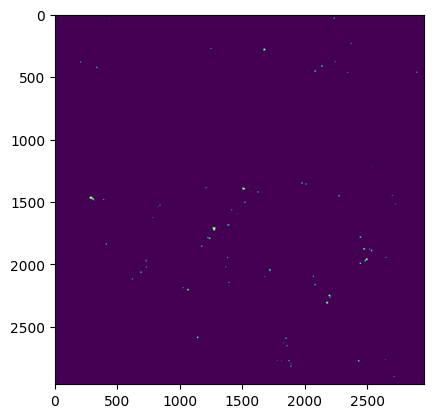

In [7]:
PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/all_data_micronuclei_no_rescale/'
mn_mask_name = '20X_c0-DAPI_A1_Tile-190.phenotype_outlines.png'
MASK_PATH = os.path.join(PATH, 'train', mn_mask_name)
mask = skimage.io.imread(MASK_PATH)
print(mask.shape)

plt.imshow(mask > 0)

# Drop blank images in bbbc039

In [4]:
# PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/'
# df = pd.read_csv(os.path.join(PATH, 'metadata.csv'))

# bbbc039 = df[df.datasets == 'BBBC039'].reset_index(drop=True)
# names = []
# for i, row in tqdm(bbbc039.iterrows()):
#     subset = row.split
#     mn_mask_name = row.filenames.replace('.tif', '.png')
#     MASK_PATH = os.path.join(PATH, subset, 'mn_masks', mn_mask_name)
#     # print(MASK_PATH)
    
#     mask = skimage.io.imread(MASK_PATH)
#     labels = skimage.morphology.label(mask)
    
#     if np.max(mask) < 1:
#         names.append(row.filenames)
#         print(row.split, row.filenames)


139it [00:00, 270.03it/s]

train IXMtest_N15_s8_w16DBEFA45-FE5A-4233-A1B9-89CA8CF81FB8.tif


159it [00:00, 273.39it/s]


In [33]:
path = '/scr/yren/cleaned_annotated_mn_datasets/'
split = 'train'

labels = sorted(df[df.split == split].datasets.unique().tolist())
print(labels)

all_data = []


for label in tqdm(labels):
    df_train = df.loc[(df.split == split) & (df.datasets == label), ['filenames', 'datasets', 'magnification', 'micron']].copy().reset_index()
    train_mn_mask_path = os.path.join(path, split, 'mn_masks')
    train_nuclei_mask_path = os.path.join(path, split, 'nuclei_masks')

    
    for i in range(df_train.shape[0]):
        mn_mask = skimage.io.imread(os.path.join(train_mn_mask_path, df_train.loc[i, 'filenames'].replace('.tif', '.png')))
        nuc_mask = skimage.io.imread(os.path.join(train_nuclei_mask_path, df_train.loc[i, 'filenames']))
        
        mag = df_train.loc[i, 'magnification']
        micron = df_train.loc[i, 'micron']

        mn_labels = skimage.morphology.label(mn_mask)
        nuc_labels = skimage.morphology.label(nuc_mask)

        
        for mn_id in range(1, np.max(mn_labels) + 1):
            mn_area = np.sum(mn_labels == mn_id)
            all_data.append({"Dataset":label, "ImageID":df_train.loc[i,"filenames"],"Type":"MN", "Area": int(mn_area), "Magnification":mag, "Micron":micron})
        
        for nuc_id in range(1, np.max(nuc_labels) + 1):
            ys, xs = np.where(nuc_labels == nuc_id)
            y, x = np.mean(ys), np.mean(xs)
            
            # filter out margin cases
            if not ((y - 25 <= 0) | (y + 25 >= nuc_mask.shape[0]) | (x - 25 <= 0) | (x + 25 >= nuc_mask.shape[1])):
                nuc_area = np.sum(nuc_labels == nuc_id)
                all_data.append({"Dataset":label, "ImageID":df_train.loc[i,"filenames"],"Type":"Nuc", "Area": int(nuc_area), "Magnification":mag, "Micron":micron})
    
    

test_data = pd.DataFrame(all_data)

['BBBC039', 'mnDINO_data_01', 'mnDINO_data_02', 'mnfinder_train']


100%|██████████| 4/4 [06:43<00:00, 100.87s/it]


In [34]:
test_data = test_data[
    (test_data.Type == 'MN') | 
    ((test_data.Type == 'Nuc') & (test_data.Area > 10))
]

In [35]:
test_data[(test_data.Area < 5) & (test_data.Dataset.isin(['BBBC039', 'mnDINO_data_01', 'mnDINO_data_02']))]

,Dataset,ImageID,Type,Area,Magnification,Micron


In [24]:
os.path.join(PATH, subset, 'mn_masks', mn_mask_name)

'/scr/yren/cleaned_annotated_mn_datasets/train/mn_masks/C2-20X_c0-DAPI-GFP_B2_Tile-20.png'

In [26]:
filenames = ['C2-20X_c0-DAPI-GFP_B2_Tile-20.tif', '20X_c0-DAPI_A1_Tile-90.tif', 'C2-20X_c0-DAPI-GFP_B3_Tile-10.tif', 'C1-20X_c0_B3_Tile-5.tif']
PATH = '/scr/yren/cleaned_annotated_mn_datasets'
SAVE_PATH = '/scr/yren/cleaned_our_data'

AREA_THRESHOLD = 5

for file in tqdm(filenames):
    subset = df[df.filenames == file].split.item()
    print(subset)
    mn_mask_name = file.replace('.tif', '.png')
    MASK_PATH = os.path.join(PATH, subset, 'mn_masks', mn_mask_name)
    # print(MASK_PATH)
    
    mask = skimage.io.imread(MASK_PATH)
    labels = skimage.morphology.label(mask)
    targets = []
    H,W = labels.shape
    need_to_resave = False
    for j in range(1, np.max(labels) + 1):
        area = np.sum(labels == j)
        ys, xs = np.where(labels == j)
        y, x = np.mean(ys), np.mean(xs)
        if area <= AREA_THRESHOLD:
            targets.append(j)
            need_to_resave = True
        
    if need_to_resave: # len(targets) > 0
        for target in targets:
            labels[labels == target] = 0
        new_labels = skimage.morphology.label(labels)
        new_labels = np.asarray(new_labels, dtype=np.uint16)
        print(f'Resaved MASK: {mn_mask_name}')
        MASK_PATH = os.path.join(SAVE_PATH, mn_mask_name)
        skimage.io.imsave(MASK_PATH, new_labels)

  0%|          | 0/4 [00:00<?, ?it/s]

train


/tmp/ipykernel_2457901/3497932916.py:34: UserWarning: /scr/yren/cleaned_our_data/C2-20X_c0-DAPI-GFP_B2_Tile-20.png is a low contrast image
  skimage.io.imsave(MASK_PATH, new_labels)
 25%|██▌       | 1/4 [00:03<00:09,  3.22s/it]

Resaved MASK: C2-20X_c0-DAPI-GFP_B2_Tile-20.png
train


/tmp/ipykernel_2457901/3497932916.py:34: UserWarning: /scr/yren/cleaned_our_data/20X_c0-DAPI_A1_Tile-90.png is a low contrast image
  skimage.io.imsave(MASK_PATH, new_labels)
 50%|█████     | 2/4 [00:07<00:07,  3.55s/it]

Resaved MASK: 20X_c0-DAPI_A1_Tile-90.png
train


/tmp/ipykernel_2457901/3497932916.py:34: UserWarning: /scr/yren/cleaned_our_data/C2-20X_c0-DAPI-GFP_B3_Tile-10.png is a low contrast image
  skimage.io.imsave(MASK_PATH, new_labels)
 75%|███████▌  | 3/4 [00:11<00:04,  4.07s/it]

Resaved MASK: C2-20X_c0-DAPI-GFP_B3_Tile-10.png
train


/tmp/ipykernel_2457901/3497932916.py:34: UserWarning: /scr/yren/cleaned_our_data/C1-20X_c0_B3_Tile-5.png is a low contrast image
  skimage.io.imsave(MASK_PATH, new_labels)
100%|██████████| 4/4 [00:13<00:00,  3.47s/it]

Resaved MASK: C1-20X_c0_B3_Tile-5.png


# Train, Test & Validation are cleaned!